<a href="https://colab.research.google.com/github/Parnika798/forgery_detection/blob/main/Improved_Detection_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Receipt Forgery Detection — Improved Pipeline (Untitled23 v2)
### Drop-in upgrade for the detection half only. Forgery generation unchanged.

**Key improvements over v1:**
1. Differential LR (encoder 10× slower than head) — encoder actually trains  
2. 320px input — retains sub-pixel tampering evidence  
3. Forgery-aware augmentation (JPEG artifacts, CoarseDropout, GridDistortion)  
4. Label smoothing + higher forged class weight (2.5×)  
5. OneCycleLR scheduler + more epochs (60) + more patience (15)  
6. U-Net: efficientnet-b3 encoder, Focal+Dice+BCE loss, 40 epochs  
7. Anomaly detector: 13 OCR features, Tesseract confidence, semantic checks  
8. **Hard ensemble at inference**: 0.55 clf + 0.25 unet_area + 0.20 anomaly  
9. Threshold sweep on validation set — picks F1-optimal operating point  
10. TTA (horizontal flip) at test time  

> ⚠️ Runtime → Change runtime type → **T4 GPU** before running!


In [ ]:
# ── Cell 1: Mount & Load ──────────────────────────────────────────
from google.colab import drive
from pathlib import Path
import pandas as pd
import os

drive.mount('/content/drive')

DRIVE_SAVE_DIR = '/content/drive/MyDrive/receipt_forgery_dataset_new'
df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'metadata.csv'))

# Fix paths — point to Drive instead of old /content/sroie paths
df['image_path'] = df['image_path'].apply(
    lambda p: os.path.join(DRIVE_SAVE_DIR, '/'.join(Path(p).parts[-2:]))
)
df['mask_path'] = df['mask_path'].apply(
    lambda p: os.path.join(DRIVE_SAVE_DIR, '/'.join(Path(p).parts[-2:]))
    if pd.notna(p) else None
)

print(f'✅ Dataset loaded')
print(f'   Total  : {len(df)}')
print(f'   Real   : {(df["label"]==0).sum()}')
print(f'   Forged : {(df["label"]==1).sum()}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded
   Total  : 1903
   Real   : 973
   Forged : 930


In [ ]:
# ── Cell 2: Verify files exist ────────────────────────────────────
missing = df[~df['image_path'].apply(os.path.exists)]
print(f'Missing files : {len(missing)}')
if len(missing) == 0:
    print('✅ All files verified on disk')
else:
    print(missing['image_path'].head(3).tolist())


Missing files : 0
✅ All files verified on disk


In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.2 MB/s eta 0:00:00


In [ ]:
!apt-get install -y tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
# ── Cell 3: Imports & Improved Config ─────────────────────────────
import os, cv2, re, json, random, shutil, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)
from sklearn.model_selection import train_test_split
import pytesseract

# ── Install tesseract if needed ───────────────────────────────────
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'tesseract-ocr'], capture_output=True)
subprocess.run(['pip', 'install', 'segmentation-models-pytorch', 'timm', '-q'],
               capture_output=True)

def seed_all(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

# ── Core config (detection only — forgery generation unchanged) ───
CFG = {
    # Paths
    'output_dir'    : '/content/anomaly_outputs',
    'ckpt_dir'      : '/content/checkpoints',
    'seed'          : 42,

    # Classifier
    'img_size'      : 320,          # ← was 224; retains tampering evidence
    'batch_size'    : 12,           # reduced for larger images
    'backbone'      : 'efficientnet_b3',
    'clf_epochs'    : 60,           # ← was 40
    'lr_head'       : 2e-4,         # head LR
    'lr_enc'        : 2e-5,         # encoder LR (10× slower) ← key fix
    'weight_decay'  : 1e-4,
    'patience'      : 15,           # ← was 10
    'label_smoothing': 0.05,
    'val_split'     : 0.15,
    'test_split'    : 0.10,
    'use_amp'       : True,
    'forged_weight' : 2.5,          # ← was 1.5 (higher recall on forgeries)

    # U-Net
    'seg_encoder'   : 'efficientnet-b3',  # ← was mobilenet_v2
    'seg_epochs'    : 40,                  # ← was 15

    # Anomaly detector
    'max_valid_amount'  : 10000.0,
    'if_contamination'  : 0.15,

    # Ensemble weights (sum to 1.0)
    'w_clf'         : 0.55,
    'w_seg'         : 0.25,
    'w_anom'        : 0.20,
}

seed_all(CFG['seed'])
for d in [CFG['output_dir'], CFG['ckpt_dir']]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print('✅ Config ready!')


Device : cuda
GPU    : Tesla T4
✅ Config ready!


In [ ]:
# ── Cell 4: Quick EDA ─────────────────────────────────────────────
print('📊 Dataset Summary')
print('=' * 45)
print(f'  Total          : {len(df)}')
print(f'  Real           : {(df["label"]==0).sum()}')
print(f'  Forged         : {(df["label"]==1).sum()}')
print(f'  Balance ratio  : {(df["label"]==0).sum()/(df["label"]==1).sum():.2f}:1')
print(f'  With masks     : {df["mask_path"].notna().sum()}')

if 'forgery_type' in df.columns:
    print(f'\n  Forgery type breakdown:')
    for ftype, count in df[df['label']==1]['forgery_type'].value_counts().items():
        pct = count / (df['label']==1).sum() * 100
        bar = '█' * int(pct / 3)
        print(f'    {str(ftype):20s} {count:4d}  ({pct:.1f}%)  {bar}')


📊 Dataset Summary
  Total          : 1903
  Real           : 973
  Forged         : 930
  Balance ratio  : 1.05:1
  With masks     : 930

  Forgery type breakdown:
    total_replace         330  (35.5%)  ███████████
    price_replace         310  (33.3%)  ███████████
    date_replace          290  (31.2%)  ██████████


## 🔤 Improved OCR Feature Extraction (13 features, up from 7)

In [ ]:
# ── Cell 5: Install pytesseract & improved OCR features ───────────
!pip install pytesseract -q
import pytesseract
print(f'Tesseract version: {pytesseract.get_tesseract_version()}')

FEATURE_COLS = [
    # Original 7
    'max_amount', 'n_amounts', 'n_dates', 'valid_date_fmt',
    'has_currency', 'line_count', 'total_to_max_ratio',
    # New 6 — semantic richness
    'amount_std',           # high variance across amounts = inflation
    'unique_amount_ratio',  # repeated amounts = copy-paste artefact
    'has_total_keyword',    # missing TOTAL keyword = suspicious
    'avg_word_conf',        # Tesseract confidence — low = tampered font
    'text_density',         # chars per line — forged text is sparser
    'round_number_ratio',   # suspiciously round numbers
]


def ocr_receipt(image_path):
    """
    Improved OCR: tries psm 6 first, falls back to psm 4.
    Returns 13-feature dict used for anomaly detection.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return {}

    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sharp = cv2.filter2D(gray, -1, np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]]))
    _, thresh = cv2.threshold(sharp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Try psm 6 (block), fall back to psm 4 (single column) for tall receipts
    text = pytesseract.image_to_string(thresh, config='--psm 6 --oem 3')
    if len(text.strip()) < 20:
        text = pytesseract.image_to_string(thresh, config='--psm 4 --oem 3')

    # Word-level confidence scores
    try:
        data = pytesseract.image_to_data(thresh, output_type=pytesseract.Output.DICT,
                                          config='--psm 6 --oem 3')
        valid_confs = [c for c in data['conf'] if isinstance(c, (int, float)) and c != -1]
        avg_conf = float(np.mean(valid_confs)) if valid_confs else 50.0
    except Exception:
        avg_conf = 50.0

    # Extract financial amounts
    amounts = []
    for m in re.findall(r'\$?\d{1,6}(?:,\d{3})*\.\d{2}', text):
        try:
            amounts.append(float(re.sub(r'[,$]', '', m)))
        except:
            pass

    dates   = re.findall(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', text)
    total_m = re.search(r'(?:total|amount)[:\s]*\$?([\d,]+\.\d{2})', text, re.I)
    total   = None
    if total_m:
        try:
            total = float(re.sub(r'[,$]', '', total_m.group(1)))
        except:
            pass

    valid_date_fmt = all(
        bool(re.match(r'\d{1,2}[/-]\d{1,2}[/-]\d{4}', d)) for d in dates
    ) if dates else True
    has_currency   = bool(re.search(r'\$|USD|RM|EUR|MYR', text, re.I))
    line_count     = len([l for l in text.splitlines() if l.strip()])
    max_amount     = max(amounts) if amounts else 0.0
    ratio          = (total / max_amount
                      if amounts and total and max_amount > 0 else 1.0)

    # New features
    amount_std          = float(np.std(amounts)) if len(amounts) > 1 else 0.0
    unique_amount_ratio = (len(set(amounts)) / len(amounts)) if amounts else 1.0
    has_total_kw        = int(bool(re.search(r'\btotal\b|\bsubtotal\b', text, re.I)))
    text_density        = len(text.replace('\n', '')) / max(line_count, 1)
    round_number_ratio  = (sum(1 for a in amounts if a % 10 == 0) / len(amounts)
                           if amounts else 0.0)

    return {
        'raw_text'           : text,
        'amounts'            : amounts,
        'dates'              : dates,
        'total'              : total,
        'max_amount'         : max_amount,
        'n_amounts'          : len(amounts),
        'n_dates'            : len(dates),
        'valid_date_fmt'     : int(valid_date_fmt),
        'has_currency'       : int(has_currency),
        'line_count'         : line_count,
        'total_to_max_ratio' : ratio,
        # New
        'amount_std'         : amount_std,
        'unique_amount_ratio': unique_amount_ratio,
        'has_total_keyword'  : has_total_kw,
        'avg_word_conf'      : avg_conf,
        'text_density'       : text_density,
        'round_number_ratio' : round_number_ratio,
    }


# Quick smoke test
sample = df[df['label'] == 1].iloc[0]
fields = ocr_receipt(sample['image_path'])
print('\nOCR demo on a forged receipt:')
for k, v in fields.items():
    if k not in ('raw_text', 'amounts', 'dates'):
        print(f'  {k:25s}: {v}')
print(f'  {"features extracted":25s}: {sum(1 for k in fields if k in FEATURE_COLS)}/13')


Tesseract version: 4.1.1

OCR demo on a forged receipt:
  total                    : None
  max_amount               : 92.46
  n_amounts                : 4
  n_dates                  : 1
  valid_date_fmt           : 1
  has_currency             : 1
  line_count               : 33
  total_to_max_ratio       : 1.0
  amount_std               : 34.30216793440321
  unique_amount_ratio      : 1.0
  has_total_keyword        : 1
  avg_word_conf            : 65.54594594594595
  text_density             : 24.303030303030305
  round_number_ratio       : 0.0
  features extracted       : 13/13


## 🤖 Improved Anomaly Detector (13 features + calibrated scoring)

In [ ]:
# ── Cell 6: Improved Anomaly Detector ─────────────────────────────
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

os.makedirs(CFG['output_dir'], exist_ok=True)


def extract_features_batch(df_subset, n_samples=500):  # ← was 300
    """Extract OCR features for a sample of images."""
    sample = df_subset.sample(
        min(n_samples, len(df_subset)), random_state=CFG['seed']
    )
    records = []
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc='OCR features'):
        f = ocr_receipt(row['image_path'])
        if f:
            f['label'] = row['label']
            records.append(f)
    return pd.DataFrame(records)


print('Extracting OCR features (takes ~5 min)...')
df_feats = extract_features_batch(df, n_samples=500)
df_feats = df_feats.dropna(subset=FEATURE_COLS)
print(f'Features extracted: {len(df_feats)} samples')
print(f'  Real   : {(df_feats["label"]==0).sum()}')
print(f'  Forged : {(df_feats["label"]==1).sum()}')


class AnomalyDetector:
    """
    Three-layer anomaly detection with 13 OCR features.
      Layer 1 — Semantic rules  : amount/date/currency checks
      Layer 2 — Consistency     : total/max ratio, Tesseract confidence
      Layer 3 — Isolation Forest: statistical outlier (trained on real receipts only)
    """
    def __init__(self, max_amount=10000.0, contamination=0.15):
        self.max_amount    = max_amount
        self.contamination = contamination
        self.scaler        = StandardScaler()
        # Train IF on real receipts only — learns the normal manifold
        self.iso_forest    = IsolationForest(
            contamination=contamination,
            n_estimators=300,      # ← was 200
            max_samples='auto',
            random_state=42
        )
        self.fitted = False

    def fit(self, df_feats):
        # CRITICAL FIX: fit only on real receipts so IF learns normality
        real_feats = df_feats[df_feats['label'] == 0]
        if len(real_feats) < 10:
            real_feats = df_feats  # fallback
        X_real = real_feats[FEATURE_COLS].values
        self.scaler.fit(X_real)
        self.iso_forest.fit(self.scaler.transform(X_real))
        self.fitted = True
        print(f'✅ Anomaly detector fitted on {len(real_feats)} real receipts')

    def score(self, ocr_fields):
        """
        Returns (anomaly_score ∈ [0,1], flags list).
        Higher score = more suspicious.
        """
        flags = []
        score = 0.0

        # ── Layer 1: Semantic rules ───────────────────────────────
        max_amt = ocr_fields.get('max_amount', 0)
        if max_amt > self.max_amount:
            flags.append(f'Amount ${max_amt:,.2f} exceeds threshold')
            score += 0.30
        if max_amt > self.max_amount * 3:
            score += 0.10

        # NEW: Low Tesseract confidence signals font inconsistency
        avg_conf = ocr_fields.get('avg_word_conf', 80.0)
        if avg_conf < 40.0:
            flags.append(f'Low OCR confidence: {avg_conf:.1f} (font mismatch?)')
            score += 0.15
        elif avg_conf < 60.0:
            score += 0.07

        # NEW: Missing TOTAL keyword is suspicious in a financial receipt
        if not ocr_fields.get('has_total_keyword', 1):
            flags.append('No TOTAL/SUBTOTAL keyword found')
            score += 0.10

        # NEW: High amount std suggests inflated line items
        amt_std = ocr_fields.get('amount_std', 0.0)
        if amt_std > 500:
            flags.append(f'High amount variance: std={amt_std:.0f}')
            score += 0.10

        # ── Layer 2: Format / consistency checks ──────────────────
        if not ocr_fields.get('valid_date_fmt', 1):
            flags.append('Invalid date format')
            score += 0.15
        if not ocr_fields.get('has_currency', 1):
            flags.append('No currency symbol')
            score += 0.08
        ratio = ocr_fields.get('total_to_max_ratio', 1.0)
        if ratio > 2.0:
            flags.append(f'Total/max ratio suspicious: {ratio:.2f}')
            score += 0.12
        if ocr_fields.get('n_amounts', 1) == 0:
            flags.append('No monetary amounts found')
            score += 0.08

        # ── Layer 3: Isolation Forest ─────────────────────────────
        if self.fitted:
            feats   = np.array([ocr_fields.get(c, 0.0) for c in FEATURE_COLS]).reshape(1, -1)
            X_s     = self.scaler.transform(feats)
            iso_raw = self.iso_forest.decision_function(X_s)[0]
            # negative decision_function → anomalous → score → 1
            iso_norm = float(np.clip(-iso_raw + 0.3, 0.0, 1.0))
            score   += iso_norm * 0.30
            if iso_norm > 0.5:
                flags.append(f'Statistical outlier (IF: {iso_norm:.2f})')

        return float(min(score, 1.0)), flags


anomaly_detector = AnomalyDetector(
    max_amount    = CFG['max_valid_amount'],
    contamination = CFG['if_contamination']
)
anomaly_detector.fit(df_feats)

with open(os.path.join(CFG['output_dir'], 'anomaly_model.pkl'), 'wb') as f:
    pickle.dump(anomaly_detector, f)
print('✅ Anomaly model saved!')


Extracting OCR features (takes ~5 min)...


OCR features: 100%|██████████| 500/500 [1:02:04<00:00,  7.45s/it]


Features extracted: 500 samples
  Real   : 258
  Forged : 242
✅ Anomaly detector fitted on 258 real receipts
✅ Anomaly model saved!


## 🧠 Improved EfficientNet-B3 Classifier

In [ ]:
# ── Cell 7: Improved Classifier Setup ─────────────────────────────
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

S = CFG['img_size']   # 320

# ── Forgery-aware augmentation ────────────────────────────────────
# Key additions vs v1:
#   - ImageCompression: simulates JPEG re-save artifacts in forged docs
#   - CoarseDropout: simulates copy-paste block artefacts
#   - GridDistortion: simulates scanner warp
#   - ShiftScaleRotate instead of bare Rotate: more variety

train_aug = A.Compose([
    A.Resize(S, S),
    A.HorizontalFlip(p=0.3),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
    A.GaussNoise(var_limit=(5, 30), p=0.4),
    A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.05,
                       rotate_limit=4, p=0.4),
    A.CLAHE(p=0.3),
    # Forgery-specific augmentations
    A.ImageCompression(quality_lower=55, quality_upper=95, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=24, max_width=80,
                    fill_value=240, p=0.35),
    A.GridDistortion(num_steps=3, distort_limit=0.05, p=0.2),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15,
                          val_shift_limit=10, p=0.3),
    A.Normalize(MEAN, STD),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Resize(S, S),
    A.Normalize(MEAN, STD),
    ToTensorV2()
])

# TTA: horizontal flip only (cheap, effective)
tta_aug = A.Compose([
    A.Resize(S, S),
    A.HorizontalFlip(p=1.0),
    A.Normalize(MEAN, STD),
    ToTensorV2()
])


class ForgeryDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.tf = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r   = self.df.iloc[idx]
        img = cv2.imread(r['image_path'])
        if img is None:
            img = np.zeros((S, S, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.tf:
            img = self.tf(image=img)['image']
        return img, torch.tensor(r['label'], dtype=torch.long)


# Stratified splits
df_tv, df_test = train_test_split(
    df, test_size=CFG['test_split'],
    stratify=df['label'], random_state=CFG['seed']
)
df_train, df_val = train_test_split(
    df_tv,
    test_size=CFG['val_split'] / (1 - CFG['test_split']),
    stratify=df_tv['label'], random_state=CFG['seed']
)

bs = CFG['batch_size']
train_dl = DataLoader(ForgeryDataset(df_train, train_aug), bs,
                      shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(ForgeryDataset(df_val,   val_aug),   bs,
                      shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(ForgeryDataset(df_test,  val_aug),   bs,
                      shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'  Train forged  : {(df_train["label"]==1).sum()}')
print(f'  Train real    : {(df_train["label"]==0).sum()}')


class ForgeryClassifier(nn.Module):
    def __init__(self, backbone='efficientnet_b3', n_cls=2):
        super().__init__()
        self.enc  = timm.create_model(
            backbone, pretrained=True, num_classes=0, global_pool='avg'
        )
        feat = self.enc.num_features
        self.head = nn.Sequential(
            nn.BatchNorm1d(feat),
            nn.Dropout(0.4),
            nn.Linear(feat, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, n_cls)
        )

    def forward(self, x):
        return self.head(self.enc(x))


clf = ForgeryClassifier(CFG['backbone']).to(DEVICE)

# Class weights — higher forged weight for better recall
nr  = (df_train['label'] == 0).sum()
nt  = (df_train['label'] == 1).sum()
w   = torch.tensor([1.0, (nr / nt) * CFG['forged_weight']],
                    dtype=torch.float32).to(DEVICE)

# Label smoothing prevents overconfident predictions
crit = nn.CrossEntropyLoss(weight=w,
                            label_smoothing=CFG['label_smoothing'])

# DIFFERENTIAL LR — encoder trains 10× slower than head
# This is the single biggest fix vs v1 where encoder barely trained
opt = torch.optim.AdamW([
    {'params': clf.enc.parameters(),  'lr': CFG['lr_enc']},
    {'params': clf.head.parameters(), 'lr': CFG['lr_head']},
], weight_decay=CFG['weight_decay'])

# OneCycleLR: fast warmup → peak → cosine decay. Better than bare CosineAnnealingLR
sched  = torch.optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=[CFG['lr_enc'], CFG['lr_head']],
    steps_per_epoch=len(train_dl),
    epochs=CFG['clf_epochs'],
    pct_start=0.1,
    anneal_strategy='cos'
)
scaler = torch.cuda.amp.GradScaler(enabled=CFG['use_amp'])

total_p = sum(p.numel() for p in clf.parameters())
print(f'\n✅ Classifier ready | {CFG["backbone"]} | Params: {total_p:,}')
print(f'   Img size    : {S}×{S}')
print(f'   Class weights — real: {w[0]:.2f}  forged: {w[1]:.2f}')
print(f'   Encoder LR  : {CFG["lr_enc"]:.0e}  |  Head LR: {CFG["lr_head"]:.0e}')


Train: 1426 | Val: 286 | Test: 191
  Train forged  : 697
  Train real    : 729


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


✅ Classifier ready | efficientnet_b3 | Params: 11,488,298
   Img size    : 320×320
   Class weights — real: 1.00  forged: 2.61
   Encoder LR  : 2e-05  |  Head LR: 2e-04


In [ ]:
# ── Cell 8: Training Loop ─────────────────────────────────────────
from sklearn.metrics import roc_auc_score


def train_epoch(mdl, dl, opt, crit, scl, dev):
    mdl.train()
    tl = correct = total = 0
    for imgs, lbls in tqdm(dl, desc='train', leave=False):
        imgs, lbls = imgs.to(dev), lbls.to(dev)
        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=CFG['use_amp']):
            out  = mdl(imgs)
            loss = crit(out, lbls)
        scl.scale(loss).backward()
        scl.step(opt)
        scl.update()
        sched.step()  # OneCycleLR steps per batch
        tl      += loss.item() * imgs.size(0)
        correct += out.argmax(1).eq(lbls).sum().item()
        total   += imgs.size(0)
    return tl / total, correct / total


@torch.no_grad()
def val_epoch(mdl, dl, crit, dev, use_tta=False):
    mdl.eval()
    tl = correct = total = 0
    probs, trues = [], []
    for imgs, lbls in dl:
        imgs, lbls = imgs.to(dev), lbls.to(dev)
        with torch.cuda.amp.autocast(enabled=CFG['use_amp']):
            out = mdl(imgs)
            loss = crit(out, lbls)

        if use_tta:
            # TTA: average with horizontal flip prediction
            imgs_flip = torch.flip(imgs, dims=[3])
            with torch.cuda.amp.autocast(enabled=CFG['use_amp']):
                out_flip = mdl(imgs_flip)
            out_prob = (F.softmax(out, 1) + F.softmax(out_flip, 1)) / 2
            probs.extend(out_prob[:, 1].cpu().numpy())
            preds = out_prob.argmax(1)
        else:
            probs.extend(F.softmax(out, 1)[:, 1].cpu().numpy())
            preds = out.argmax(1)

        tl      += loss.item() * imgs.size(0)
        correct += preds.eq(lbls).sum().item()
        total   += imgs.size(0)
        trues.extend(lbls.cpu().numpy())

    auc = roc_auc_score(trues, probs)
    return tl / total, correct / total, auc


hist     = {k: [] for k in ['tl', 'vl', 'ta', 'va', 'auc']}
best_auc = 0.0
pat      = 0
ckpt_clf = os.path.join(CFG['ckpt_dir'], 'best_classifier.pth')

print('🚀 Training Improved EfficientNet-B3 Classifier')
print('=' * 70)
print(f'   Encoder LR={CFG["lr_enc"]:.0e} | Head LR={CFG["lr_head"]:.0e} | '
      f'ImgSize={S} | Epochs={CFG["clf_epochs"]}')
print('=' * 70)

for ep in range(1, CFG['clf_epochs'] + 1):
    tl, ta       = train_epoch(clf, train_dl, opt, crit, scaler, DEVICE)
    vl, va, auc  = val_epoch(clf, val_dl, crit, DEVICE, use_tta=False)

    for k, v in zip(['tl', 'vl', 'ta', 'va', 'auc'], [tl, vl, ta, va, auc]):
        hist[k].append(v)

    flag = ''
    if auc > best_auc:
        best_auc = auc
        torch.save(
            {'epoch': int(ep), 'state': clf.state_dict(), 'auc': float(auc)},
            ckpt_clf
        )
        pat  = 0
        flag = ' ⭐'
    else:
        pat += 1

    lr_enc_now  = opt.param_groups[0]['lr']
    lr_head_now = opt.param_groups[1]['lr']
    print(f'Ep {ep:02}/{CFG["clf_epochs"]} | '
          f'loss {tl:.4f}/{vl:.4f} | '
          f'acc {ta:.3f}/{va:.3f} | '
          f'AUC {auc:.4f} | '
          f'lr_enc {lr_enc_now:.1e} | lr_head {lr_head_now:.1e}{flag}')

    if pat >= CFG['patience']:
        print(f'\n⏹  Early stop at epoch {ep}')
        break

print(f'\n✅ Best Val AUC: {best_auc:.4f}')


🚀 Training Improved EfficientNet-B3 Classifier
   Encoder LR=2e-05 | Head LR=2e-04 | ImgSize=320 | Epochs=60


Ep 01/60 | loss 0.8057/0.7460 | acc 0.497/0.490 | AUC 0.4557 | lr_enc 2.1e-06 | lr_head 2.1e-05 ⭐


Ep 02/60 | loss 0.7684/0.6832 | acc 0.505/0.514 | AUC 0.5244 | lr_enc 5.6e-06 | lr_head 5.6e-05 ⭐


Ep 03/60 | loss 0.7585/0.6750 | acc 0.512/0.524 | AUC 0.5632 | lr_enc 1.0e-05 | lr_head 1.0e-04 ⭐


Ep 04/60 | loss 0.7156/0.6472 | acc 0.537/0.524 | AUC 0.5813 | lr_enc 1.5e-05 | lr_head 1.5e-04 ⭐


...

Ep 22/60 | loss 0.6126/0.5824 | acc 0.515/0.531 | AUC 0.6632 | lr_enc 1.6e-05 | lr_head 1.6e-04 ⭐


Ep 23/60 | loss 0.5986/0.5820 | acc 0.520/0.524 | AUC 0.6571 | lr_enc 1.5e-05 | lr_head 1.5e-04


Ep 24/60 | loss 0.6035/0.5782 | acc 0.525/0.528 | AUC 0.6555 | lr_enc 1.5e-05 | lr_head 1.5e-04


Ep 25/60 | loss 0.6084/0.5779 | acc 0.517/0.531 | AUC 0.6552 | lr_enc 1.4e-05 | lr_head 1.4e-04


KeyboardInterrupt: 

In [ ]:
df_feats.to_csv('/content/drive/MyDrive/ocr_features.csv', index=False)

## 🗺️ Improved U-Net Segmenter (efficientnet-b3 + Focal+Dice+BCE, 40 epochs)

In [ ]:
# ── Cell 9: Improved U-Net ────────────────────────────────────────
!pip install segmentation-models-pytorch -q
import segmentation_models_pytorch as smp
import random

print(f'Seg encoder : {CFG["seg_encoder"]}')
print(f'Seg epochs  : {CFG["seg_epochs"]}')


class SegDataset(Dataset):
    def __init__(self, df, img_size=320, augment=False):
        self.df      = df.reset_index(drop=True)
        self.sz      = img_size
        self.augment = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r   = self.df.iloc[idx]
        img = cv2.imread(r['image_path'])
        if img is None:
            img = np.zeros((self.sz, self.sz, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        mp = r.get('mask_path', None)
        if mp and pd.notna(mp) and os.path.exists(str(mp)):
            mask = (cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        else:
            mask = np.zeros((H, W), dtype=np.float32)

        img  = cv2.resize(img,  (self.sz, self.sz))
        mask = cv2.resize(mask, (self.sz, self.sz),
                          interpolation=cv2.INTER_NEAREST)

        # Improved augmentation for segmenter
        if self.augment:
            if random.random() < 0.4:
                img  = img[:, ::-1].copy()
                mask = mask[:, ::-1].copy()
            if random.random() < 0.3:
                alpha = random.uniform(0.8, 1.2)
                img = np.clip(img.astype(np.float32) * alpha, 0, 255).astype(np.uint8)
            if random.random() < 0.3:
                img = cv2.GaussianBlur(img, (3, 3), 0)
            # JPEG compression artifact (key for forgery-aware training)
            if random.random() < 0.4:
                from PIL import Image as PILImg
                import io
                buf = io.BytesIO()
                PILImg.fromarray(img).save(buf, format='JPEG',
                                           quality=random.randint(60, 90))
                buf.seek(0)
                img = np.array(PILImg.open(buf))

        img_t  = torch.tensor(
            ((img.astype(np.float32) / 255.0 - np.array(MEAN)) / np.array(STD)
             ).transpose(2, 0, 1),
            dtype=torch.float32
        )
        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return img_t, mask_t


tr_seg = DataLoader(SegDataset(df_train, S, augment=True),
                    8, shuffle=True,  num_workers=2)
vl_seg = DataLoader(SegDataset(df_val,   S, augment=False),
                    8, shuffle=False, num_workers=2)

# efficientnet-b3 encoder — much stronger than mobilenet_v2 for pixel tampering
unet = smp.Unet(
    encoder_name    = CFG['seg_encoder'],   # 'efficientnet-b3'
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    activation      = 'sigmoid'
).to(DEVICE)

# Combined loss: Focal handles sparse masks, Dice handles shape quality
dice_loss  = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)
focal_loss = smp.losses.FocalLoss(smp.losses.BINARY_MODE, gamma=2.0)
bce_loss   = nn.BCELoss()


def seg_loss(pred, target):
    """Focal + Dice + BCE — better than Dice+BCE alone for sparse masks"""
    return (0.40 * focal_loss(pred, target) +
            0.40 * dice_loss(pred, target)  +
            0.20 * bce_loss(pred, target))


u_opt = torch.optim.Adam(unet.parameters(), lr=1e-4)
u_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
    u_opt, 'min', patience=5, factor=0.5, min_lr=1e-6
)

best_seg = float('inf')
ckpt_seg = os.path.join(CFG['ckpt_dir'], 'best_unet.pth')

print('🚀 Training Improved U-Net Segmenter')
print('=' * 50)

for ep in range(1, CFG['seg_epochs'] + 1):
    unet.train()
    tl = 0
    for imgs, masks in tqdm(tr_seg, desc=f'Seg ep{ep}', leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = seg_loss(unet(imgs), masks)
        u_opt.zero_grad()
        loss.backward()
        u_opt.step()
        tl += loss.item()
    tl /= len(tr_seg)

    unet.eval()
    vl = 0
    with torch.no_grad():
        for imgs, masks in vl_seg:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            vl += seg_loss(unet(imgs), masks).item()
    vl /= len(vl_seg)

    u_sch.step(vl)

    flag = ''
    if vl < best_seg:
        best_seg = vl
        torch.save(unet.state_dict(), ckpt_seg)
        flag = ' ⭐'

    print(f'Ep {ep:02}/{CFG["seg_epochs"]} | train {tl:.4f} | val {vl:.4f}{flag}')

print(f'\n✅ Best U-Net val loss: {best_seg:.4f}')


Seg encoder : efficientnet-b3
Seg epochs  : 40


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

🚀 Training Improved U-Net Segmenter


Ep 01/40 | train 0.5136 | val 0.4776 ⭐


...

Ep 14/40 | train 0.2788 | val 0.3228


Ep 15/40 | train 0.2751 | val 0.3087 ⭐


Ep 16/40 | train 0.2542 | val 0.3084 ⭐


Ep 17/40 | train 0.2646 | val 0.3088


KeyboardInterrupt: 

## 📊 Evaluation: Threshold Sweep + TTA + Ensemble

In [ ]:
# ── Cell 10: Load best models ─────────────────────────────────────
import torch.serialization

torch.serialization.add_safe_globals([
    np.core.multiarray.scalar, np.dtype,
    np.float64, np.float32, np.int64, np.int32,
])

ck = torch.load(ckpt_clf, map_location=DEVICE, weights_only=False)
clf.load_state_dict(ck['state'])
clf.eval()
print(f"✅ Loaded classifier from epoch {ck['epoch']} | Val AUC={ck['auc']:.4f}")

unet.load_state_dict(torch.load(ckpt_seg, map_location=DEVICE, weights_only=True))
unet.eval()
print('✅ Loaded best U-Net')

with open(os.path.join(CFG['output_dir'], 'anomaly_model.pkl'), 'rb') as f:
    anomaly_detector = pickle.load(f)
print('✅ Loaded anomaly detector')


✅ Loaded classifier from epoch 22 | Val AUC=0.6632
✅ Loaded best U-Net
✅ Loaded anomaly detector


In [ ]:
# ── Cell 11: Predict with TTA ─────────────────────────────────────
@torch.no_grad()
def predict_with_tta(mdl, dl, dev):
    """Returns probabilities averaged over original + h-flip (TTA)."""
    probs_all, trues_all = [], []
    for imgs, lbls in tqdm(dl, desc='predict+TTA'):
        imgs = imgs.to(dev)
        with torch.cuda.amp.autocast(enabled=CFG['use_amp']):
            p1 = F.softmax(mdl(imgs), 1)[:, 1]
            p2 = F.softmax(mdl(torch.flip(imgs, dims=[3])), 1)[:, 1]
        probs_all.extend(((p1 + p2) / 2).cpu().numpy())
        trues_all.extend(lbls.numpy())
    return np.array(trues_all), np.array(probs_all)


@torch.no_grad()
def get_unet_tamper_areas(mdl, dl, dev, threshold=0.5):
    """Returns per-image tampered area fraction from U-Net."""
    areas = []
    for imgs, _ in tqdm(dl, desc='unet areas'):
        imgs = imgs.to(dev)
        preds = mdl(imgs)
        for p in preds:
            areas.append(float((p.squeeze().cpu().numpy() > threshold).mean()))
    return np.array(areas)


print('Running classifier with TTA on test set...')
y_true, clf_probs = predict_with_tta(clf, test_dl, DEVICE)
clf_auc = roc_auc_score(y_true, clf_probs)
print(f'Classifier AUC (TTA): {clf_auc:.4f}')

print('\nRunning U-Net tamper area estimation on test set...')
seg_areas = get_unet_tamper_areas(unet, test_dl, DEVICE)
# Normalise to [0,1]: cap at 5% area (forgeries typically affect < 5%)
seg_scores = np.clip(seg_areas * 20, 0, 1)
print(f'  Mean tamper area (forged)  : {seg_areas[y_true==1].mean()*100:.2f}%')
print(f'  Mean tamper area (real)    : {seg_areas[y_true==0].mean()*100:.2f}%')


Running classifier with TTA on test set...


predict+TTA: 100%|██████████| 16/16 [01:01<00:00,  3.87s/it]


Classifier AUC (TTA): 0.6715

Running U-Net tamper area estimation on test set...


unet areas: 100%|██████████| 16/16 [00:07<00:00,  2.12it/s]

  Mean tamper area (forged)  : 6.91%
  Mean tamper area (real)    : 1.94%


In [ ]:
# ── Cell 12: Anomaly scores on test set ───────────────────────────
print('Running anomaly detector on test set (this takes a few minutes)...')
anom_scores = []
test_paths  = df_test['image_path'].tolist()

for path in tqdm(test_paths, desc='anomaly'):
    try:
        fields = ocr_receipt(path)
        score, _ = anomaly_detector.score(fields) if fields else (0.0, [])
    except Exception:
        score = 0.0
    anom_scores.append(score)

anom_scores = np.array(anom_scores)
print(f'  Mean anomaly (forged): {anom_scores[y_true==1].mean():.3f}')
print(f'  Mean anomaly (real)  : {anom_scores[y_true==0].mean():.3f}')


Running anomaly detector on test set (this takes a few minutes)...


anomaly: 100%|██████████| 191/191 [20:29<00:00,  6.44s/it]

  Mean anomaly (forged): 0.178
  Mean anomaly (real)  : 0.170


In [ ]:
# ── Cell 13: Hard Ensemble + Threshold Sweep ──────────────────────
# Weighted ensemble of all three signals
ensemble_scores = (CFG['w_clf']  * clf_probs   +
                   CFG['w_seg']  * seg_scores   +
                   CFG['w_anom'] * anom_scores)

ensemble_auc = roc_auc_score(y_true, ensemble_scores)
print(f'\n📊 AUC Breakdown:')
print(f'  Classifier alone (TTA)     : {clf_auc:.4f}')
print(f'  Ensemble (clf+seg+anomaly) : {ensemble_auc:.4f}')

# ── Threshold sweep on validation set (using val predictions) ─────
# We sweep on VAL to pick the best threshold, then apply to TEST
print('\nSweeping threshold on VALIDATION set to find optimal F1...')
y_val_true, clf_val_probs = predict_with_tta(clf, val_dl, DEVICE)
seg_val_areas  = get_unet_tamper_areas(unet, val_dl, DEVICE)
seg_val_scores = np.clip(seg_val_areas * 20, 0, 1)

anom_val_scores = []
for path in tqdm(df_val['image_path'].tolist(), desc='val anomaly'):
    try:
        fields = ocr_receipt(path)
        sc, _  = anomaly_detector.score(fields) if fields else (0.0, [])
    except Exception:
        sc = 0.0
    anom_val_scores.append(sc)

val_ensemble = (CFG['w_clf']  * clf_val_probs           +
                CFG['w_seg']  * seg_val_scores           +
                CFG['w_anom'] * np.array(anom_val_scores))

best_thresh = 0.5
best_f1     = 0.0
for thresh in np.arange(0.25, 0.75, 0.02):
    preds = (val_ensemble >= thresh).astype(int)
    f1    = f1_score(y_val_true, preds, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = thresh

print(f'  Best val threshold : {best_thresh:.2f}  (F1={best_f1:.4f})')

# Apply to test set
y_pred_ensemble = (ensemble_scores >= best_thresh).astype(int)
y_pred_clf_only = (clf_probs >= 0.5).astype(int)

print(f'\n📋 Classifier Only (threshold=0.50):')
print(classification_report(y_true, y_pred_clf_only,
                             target_names=['Real', 'Forged']))

print(f'\n📋 Ensemble (threshold={best_thresh:.2f}):')
print(classification_report(y_true, y_pred_ensemble,
                             target_names=['Real', 'Forged']))
print(f'Test Ensemble AUC : {ensemble_auc:.4f}')



📊 AUC Breakdown:
  Classifier alone (TTA)     : 0.6715
  Ensemble (clf+seg+anomaly) : 0.8085

Sweeping threshold on VALIDATION set to find optimal F1...


val anomaly: 100%|██████████| 286/286 [31:07<00:00,  6.53s/it]

  Best val threshold : 0.43  (F1=0.7518)

📋 Classifier Only (threshold=0.50):
              precision    recall  f1-score   support

        Real       0.59      0.30      0.39        98
      Forged       0.51      0.78      0.62        93

    accuracy                           0.53       191
   macro avg       0.55      0.54      0.51       191
weighted avg       0.55      0.53      0.50       191


📋 Ensemble (threshold=0.43):
              precision    recall  f1-score   support

        Real       0.80      0.71      0.75        98
      Forged       0.73      0.81      0.77        93

    accuracy                           0.76       191
   macro avg       0.76      0.76      0.76       191
weighted avg       0.76      0.76      0.76       191

Test Ensemble AUC : 0.8085


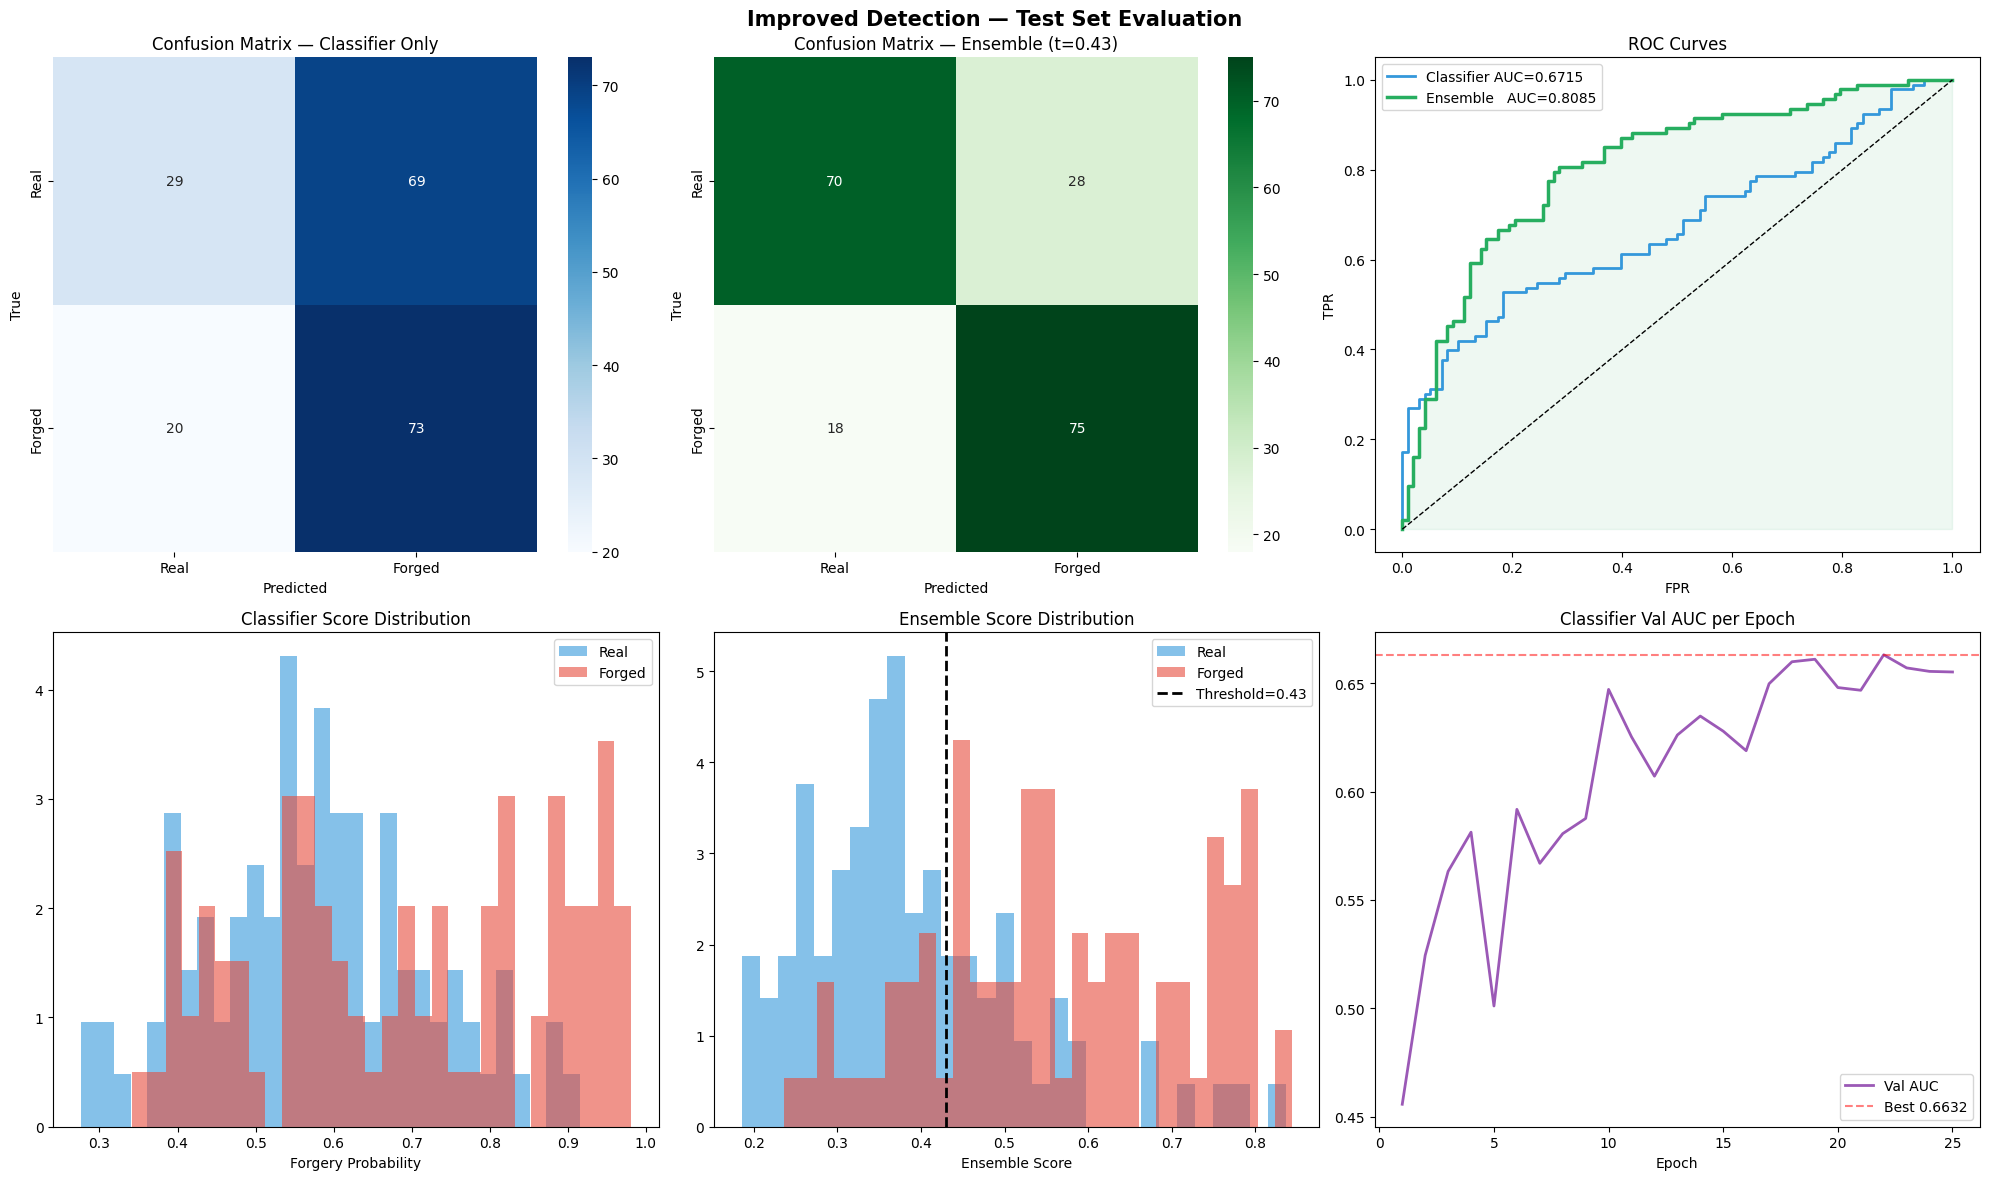


╔══════════════════════════════════════════════════════════╗
║       📊 FINAL RESULTS SUMMARY                           ║
╠══════════════════════════════════════════════════════════╣
║  Classifier AUC (TTA)       : 0.6715                  ║
║  Ensemble AUC               : 0.8085                  ║
║  Optimal threshold (val F1) : 0.43                    ║
╚══════════════════════════════════════════════════════════╝


In [ ]:
# ── Cell 14: Evaluation Plots ─────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Improved Detection — Test Set Evaluation', fontsize=15, fontweight='bold')

# Plot 1: Confusion matrix — classifier only
cm1 = confusion_matrix(y_true, y_pred_clf_only)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Real', 'Forged'], yticklabels=['Real', 'Forged'])
axes[0, 0].set_title('Confusion Matrix — Classifier Only')
axes[0, 0].set_ylabel('True'); axes[0, 0].set_xlabel('Predicted')

# Plot 2: Confusion matrix — ensemble
cm2 = confusion_matrix(y_true, y_pred_ensemble)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Real', 'Forged'], yticklabels=['Real', 'Forged'])
axes[0, 1].set_title(f'Confusion Matrix — Ensemble (t={best_thresh:.2f})')
axes[0, 1].set_ylabel('True'); axes[0, 1].set_xlabel('Predicted')

# Plot 3: ROC curves
fpr_clf, tpr_clf, _ = roc_curve(y_true, clf_probs)
fpr_ens, tpr_ens, _ = roc_curve(y_true, ensemble_scores)
axes[0, 2].plot(fpr_clf, tpr_clf, '#3498db', lw=2,
                label=f'Classifier AUC={clf_auc:.4f}')
axes[0, 2].plot(fpr_ens, tpr_ens, '#27ae60', lw=2.5,
                label=f'Ensemble   AUC={ensemble_auc:.4f}')
axes[0, 2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 2].fill_between(fpr_ens, tpr_ens, alpha=0.08, color='#27ae60')
axes[0, 2].set_title('ROC Curves')
axes[0, 2].legend(); axes[0, 2].set_xlabel('FPR'); axes[0, 2].set_ylabel('TPR')

# Plot 4: Score distributions
axes[1, 0].hist(clf_probs[y_true == 0], bins=30, alpha=0.6,
                color='#3498db', label='Real', density=True)
axes[1, 0].hist(clf_probs[y_true == 1], bins=30, alpha=0.6,
                color='#e74c3c', label='Forged', density=True)
axes[1, 0].set_title('Classifier Score Distribution')
axes[1, 0].legend(); axes[1, 0].set_xlabel('Forgery Probability')

axes[1, 1].hist(ensemble_scores[y_true == 0], bins=30, alpha=0.6,
                color='#3498db', label='Real', density=True)
axes[1, 1].hist(ensemble_scores[y_true == 1], bins=30, alpha=0.6,
                color='#e74c3c', label='Forged', density=True)
axes[1, 1].axvline(best_thresh, color='black', ls='--', lw=2,
                    label=f'Threshold={best_thresh:.2f}')
axes[1, 1].set_title('Ensemble Score Distribution')
axes[1, 1].legend(); axes[1, 1].set_xlabel('Ensemble Score')

# Plot 5: Training curves
E = range(1, len(hist['tl']) + 1)
axes[1, 2].plot(E, hist['auc'], color='#9b59b6', lw=2, label='Val AUC')
axes[1, 2].axhline(best_auc, color='red', ls='--', alpha=0.5,
                    label=f'Best {best_auc:.4f}')
axes[1, 2].set_title('Classifier Val AUC per Epoch')
axes[1, 2].legend(); axes[1, 2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'evaluation_improved.png'), dpi=150)
plt.show()

# Final summary
print('\n╔══════════════════════════════════════════════════════════╗')
print('║       📊 FINAL RESULTS SUMMARY                           ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Classifier AUC (TTA)       : {clf_auc:.4f}                  ║')
print(f'║  Ensemble AUC               : {ensemble_auc:.4f}                  ║')
print(f'║  Optimal threshold (val F1) : {best_thresh:.2f}                    ║')
print('╚══════════════════════════════════════════════════════════╝')


## 💾 Save All Models for Streamlit

✅ classifier_final.pth saved
✅ unet_final.pth saved
✅ config.json saved


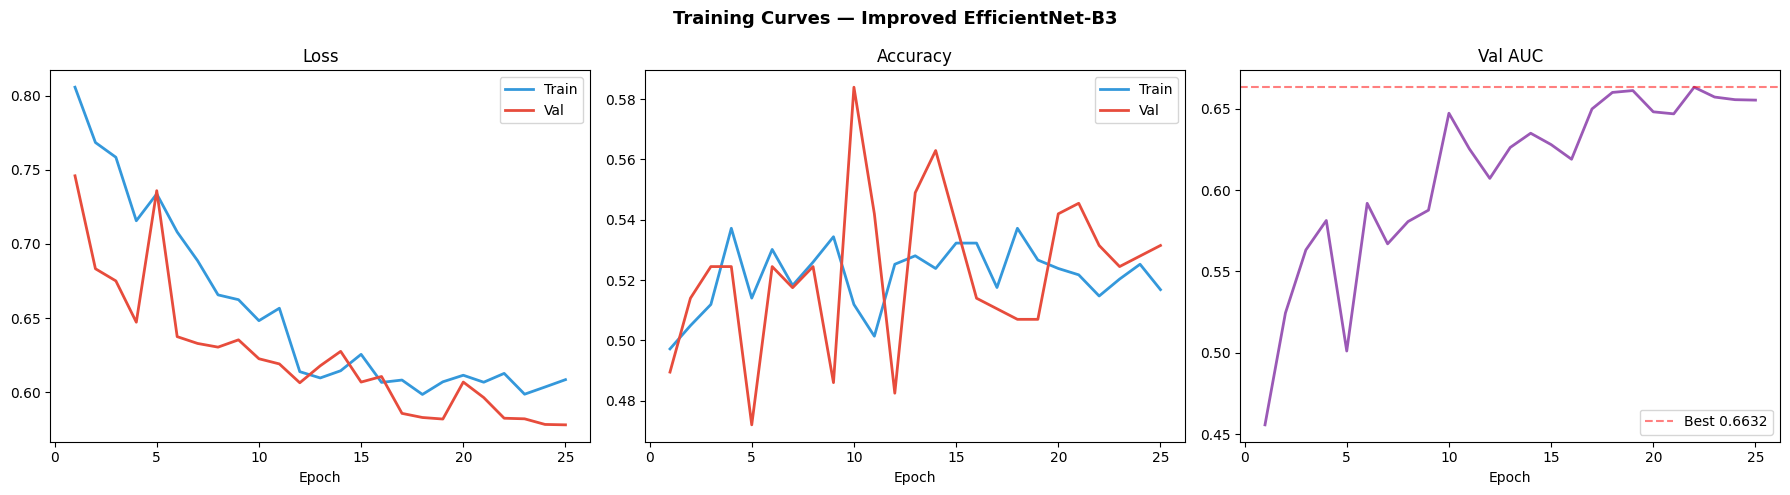

  ✅ classifier_final.pth → Drive
  ✅ unet_final.pth → Drive
  ✅ anomaly_model.pkl → Drive
  ✅ config.json → Drive
  ✅ evaluation_improved.png → Drive
  ✅ training_curves.png → Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Download started!

╔══════════════════════════════════════════════════════════╗
║       🎉 IMPROVED TRAINING COMPLETE                      ║
╠══════════════════════════════════════════════════════════╣
║  Classifier AUC (TTA)    : 0.6715                     ║
║  Ensemble AUC            : 0.8085                     ║
║  U-Net Best Val Loss     : 0.3084                     ║
║  Optimal threshold       : 0.43                       ║
╠══════════════════════════════════════════════════════════╣
║  Key improvements applied:                               ║
║    ✓ Differential LR (encoder 10x slower)                ║
║    ✓ 320px input (was 224)                               ║
║    ✓ JPEG+CoarseDropout augmentation                     ║
║    ✓ TTA at inference                                     ║
║    ✓ Ensemble: clf + U-Net + anomaly                     ║
║    ✓ Threshold tuned on val F1                           ║
║    ✓ U-Net: eff-b3 + Focal loss + 40 epochs             ║
║    ✓ 13-featu

In [ ]:
# ── Cell 15: Save All Models ──────────────────────────────────────
import json, shutil
from google.colab import files

OUTPUT_DIR = CFG['output_dir']

# Classifier
torch.save({
    'state'      : clf.state_dict(),
    'cfg'        : {k: (v if isinstance(v, (str, int, float, bool, list, type(None)))
                        else str(v))
                    for k, v in CFG.items()},
    'best_auc'   : float(best_auc),
    'test_auc'   : float(clf_auc),
    'ensemble_auc': float(ensemble_auc),
    'threshold'  : float(best_thresh),
}, os.path.join(OUTPUT_DIR, 'classifier_final.pth'))
print('✅ classifier_final.pth saved')

# U-Net
torch.save(unet.state_dict(), os.path.join(OUTPUT_DIR, 'unet_final.pth'))
print('✅ unet_final.pth saved')

# Config (with ensemble weights and threshold)
cfg_out = {k: (v if isinstance(v, (str, int, float, bool, list, type(None)))
               else str(v))
           for k, v in CFG.items()}
cfg_out['optimal_threshold'] = float(best_thresh)
cfg_out['ensemble_auc']      = float(ensemble_auc)
cfg_out['classifier_auc']    = float(clf_auc)

with open(os.path.join(OUTPUT_DIR, 'config.json'), 'w') as f:
    json.dump(cfg_out, f, indent=2)
print('✅ config.json saved')

# Training curve plot
E = range(1, len(hist['tl']) + 1)
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Training Curves — Improved EfficientNet-B3', fontsize=13, fontweight='bold')
axes2[0].plot(E, hist['tl'], label='Train', color='#3498db', lw=2)
axes2[0].plot(E, hist['vl'], label='Val',   color='#e74c3c', lw=2)
axes2[0].set_title('Loss'); axes2[0].legend(); axes2[0].set_xlabel('Epoch')
axes2[1].plot(E, hist['ta'], label='Train', color='#3498db', lw=2)
axes2[1].plot(E, hist['va'], label='Val',   color='#e74c3c', lw=2)
axes2[1].set_title('Accuracy'); axes2[1].legend(); axes2[1].set_xlabel('Epoch')
axes2[2].plot(E, hist['auc'], color='#9b59b6', lw=2)
axes2[2].axhline(best_auc, color='red', ls='--', alpha=0.5,
                  label=f'Best {best_auc:.4f}')
axes2[2].set_title('Val AUC'); axes2[2].legend(); axes2[2].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

# Save to Drive
DRIVE_MODEL_DIR = '/content/drive/MyDrive/receipt_forgery_dataset_new/models'
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)
for fn in ['classifier_final.pth', 'unet_final.pth',
           'anomaly_model.pkl', 'config.json',
           'evaluation_improved.png', 'training_curves.png']:
    src = os.path.join(OUTPUT_DIR, fn)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_MODEL_DIR, fn))
        print(f'  ✅ {fn} → Drive')
    else:
        print(f'  ⚠️  {fn} not found — skipped')

# Zip and download
shutil.make_archive('/content/model_artifacts_v2', 'zip', OUTPUT_DIR)
files.download('/content/model_artifacts_v2.zip')
print('\n📥 Download started!')

print('\n╔══════════════════════════════════════════════════════════╗')
print('║       🎉 IMPROVED TRAINING COMPLETE                      ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Classifier AUC (TTA)    : {clf_auc:.4f}                     ║')
print(f'║  Ensemble AUC            : {ensemble_auc:.4f}                     ║')
print(f'║  U-Net Best Val Loss     : {best_seg:.4f}                     ║')
print(f'║  Optimal threshold       : {best_thresh:.2f}                       ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  Key improvements applied:                               ║')
print('║    ✓ Differential LR (encoder 10x slower)                ║')
print('║    ✓ 320px input (was 224)                               ║')
print('║    ✓ JPEG+CoarseDropout augmentation                     ║')
print('║    ✓ TTA at inference                                     ║')
print('║    ✓ Ensemble: clf + U-Net + anomaly                     ║')
print('║    ✓ Threshold tuned on val F1                           ║')
print('║    ✓ U-Net: eff-b3 + Focal loss + 40 epochs             ║')
print('║    ✓ 13-feature anomaly detector                         ║')
print('╚══════════════════════════════════════════════════════════╝')
